# Yulu Bike Sharing Demand Analysis

## Problem Statement
Yulu, India’s leading micro-mobility service provider, aims to identify significant variables that predict the demand for shared electric cycles. The goal is to understand how well these variables describe demand in the Indian market.

## Dataset Overview
The dataset `bike_sharing.csv` contains information related to bike rental demand, along with environmental and temporal features.

## Analysis Steps Taken:
1.  **Data Loading & Initial Inspection**: The dataset was loaded, its shape, column information, and statistical summary were examined. Missing values and duplicates were also checked and handled.
2.  **Numerical Variable Distribution & Outlier Detection**: Histograms were plotted to visualize the distributions of numerical features (`temp`, `atemp`, `humidity`, `windspeed`), and boxplots were used to identify outliers.
3.  **Correlation Analysis**: A heatmap was generated to visualize the correlation between numerical variables. An insight was noted regarding the high correlation between 'temp' and 'atemp', suggesting potential multicollinearity.
4.  **Hypothesis Testing**: Several hypothesis tests were performed:
    *   **Independent T-test**: To compare the average demand on weekdays versus weekends.
    *   **One-Sample T-test**: To check if the mean demand is significantly different from 500.
    *   **One-Sample T-test (High Demand Days)**: To determine if the average temperature on high-demand days differs from 25°C.
    *   **Chi-square Test**: To assess the independence of weather conditions and seasons.

<div style="padding: 15px; border-radius: 10px; background-color: #f0f7ff; border-left: 6px solid #2196f3;">
    <h2 style="color: #0d47a1; margin-top: 0;">Step 1: Environment Setup & Data Ingestion</h2>
    <p>We are initializing the analytics environment by importing <b>SciPy</b> for rigorous statistical testing and <b>Seaborn/Matplotlib</b> for high-end visualization. The primary objective is to investigate which factors—such as weather, season, and day of the week—significantly impact the demand for shared electric cycles in the Indian market.</p>
</div>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, ttest_1samp, ttest_rel, chisquare, chi2_contingency

# Problem Statement:
# Yulu wants to identify significant variables predicting the demand for shared electric cycles
# and how well these variables describe demand in the Indian market.

# Load the dataset
df = pd.read_csv('../data/bike_sharing.csv')

<div style="padding: 10px; background-color: #e8f5e9; border-radius: 5px; border: 1px solid #c8e6c9;">
    <span style="color: #2e7d32;"><b>✅ Status:</b> Environment successfully configured. The Yulu dataset has been ingested and is ready for exploratory data analysis (EDA) and hypothesis testing.</span>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #fff9c4; border-left: 6px solid #fbc02d;">
    <h2 style="color: #827717; margin-top: 0;">Step 2: Data Quality Audit & Cleaning</h2>
    <p>We are conducting a deep dive into the dataset's integrity by examining its shape, column types, and statistical distribution. This stage is crucial for identifying missing values or duplicate records that could skew our hypothesis results.</p>
</div>

In [5]:
# 1. Examine dataset structure and statistical summary
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Column Info ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())

# 2. Identify missing values and duplicates
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)
print("\nDuplicates handled. New Shape:", df.shape)

--- Dataset Shape ---
(10886, 12)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB

--- Statistical Summary ---
             season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       2

In [6]:
import pandas as pd

# Converting datetime to actual datetime object for future time-series potential
df['datetime'] = pd.to_datetime(df['datetime'])

# Sanity Check: Total count should equal casual + registered
data_consistency_check = (df['casual'] + df['registered'] == df['count']).all()
print(f"Data Consistency Check (casual + registered == count): {data_consistency_check}")

# Quick check on the number of unique values for categorical features
for col in ['season', 'weather', 'holiday', 'workingday']:
    print(f"Unique values in {col}: {df[col].unique()}")

display(df.head())

Data Consistency Check (casual + registered == count): True
Unique values in season: [1 2 3 4]
Unique values in weather: [1 2 3 4]
Unique values in holiday: [0 1]
Unique values in workingday: [0 1]


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


<div style="padding: 10px; background-color: #f1f8e9; border-radius: 5px; border: 1px solid #dcedc8;">
    <p style="color: #33691e; margin: 0;"><b>Inference:</b> The audit confirms a robust dataset of 10,886 records. No missing values were detected across the 12 features, and the data types (integers and floats) are correctly aligned for statistical computation. The removal of duplicates ensures that each observation represents a unique rental event.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #f3e5f5; border-left: 6px solid #9c27b0;">
    <h2 style="color: #4a148c; margin-top: 0;">Step 3: Univariate Analysis & Outlier Detection</h2>
    <p>In this phase, we utilize a 2x4 grid of subplots to simultaneously analyze the <b>distribution</b> and <b>outliers</b> of our key numerical features.
    <br>• <b>Histograms:</b> Used to assess the spread and central tendency of temperature, humidity, and windspeed.
    <br>• <b>Boxplots:</b> Essential for identifying extreme values (outliers) that might necessitate data clipping or specialized handling.</p>
</div>

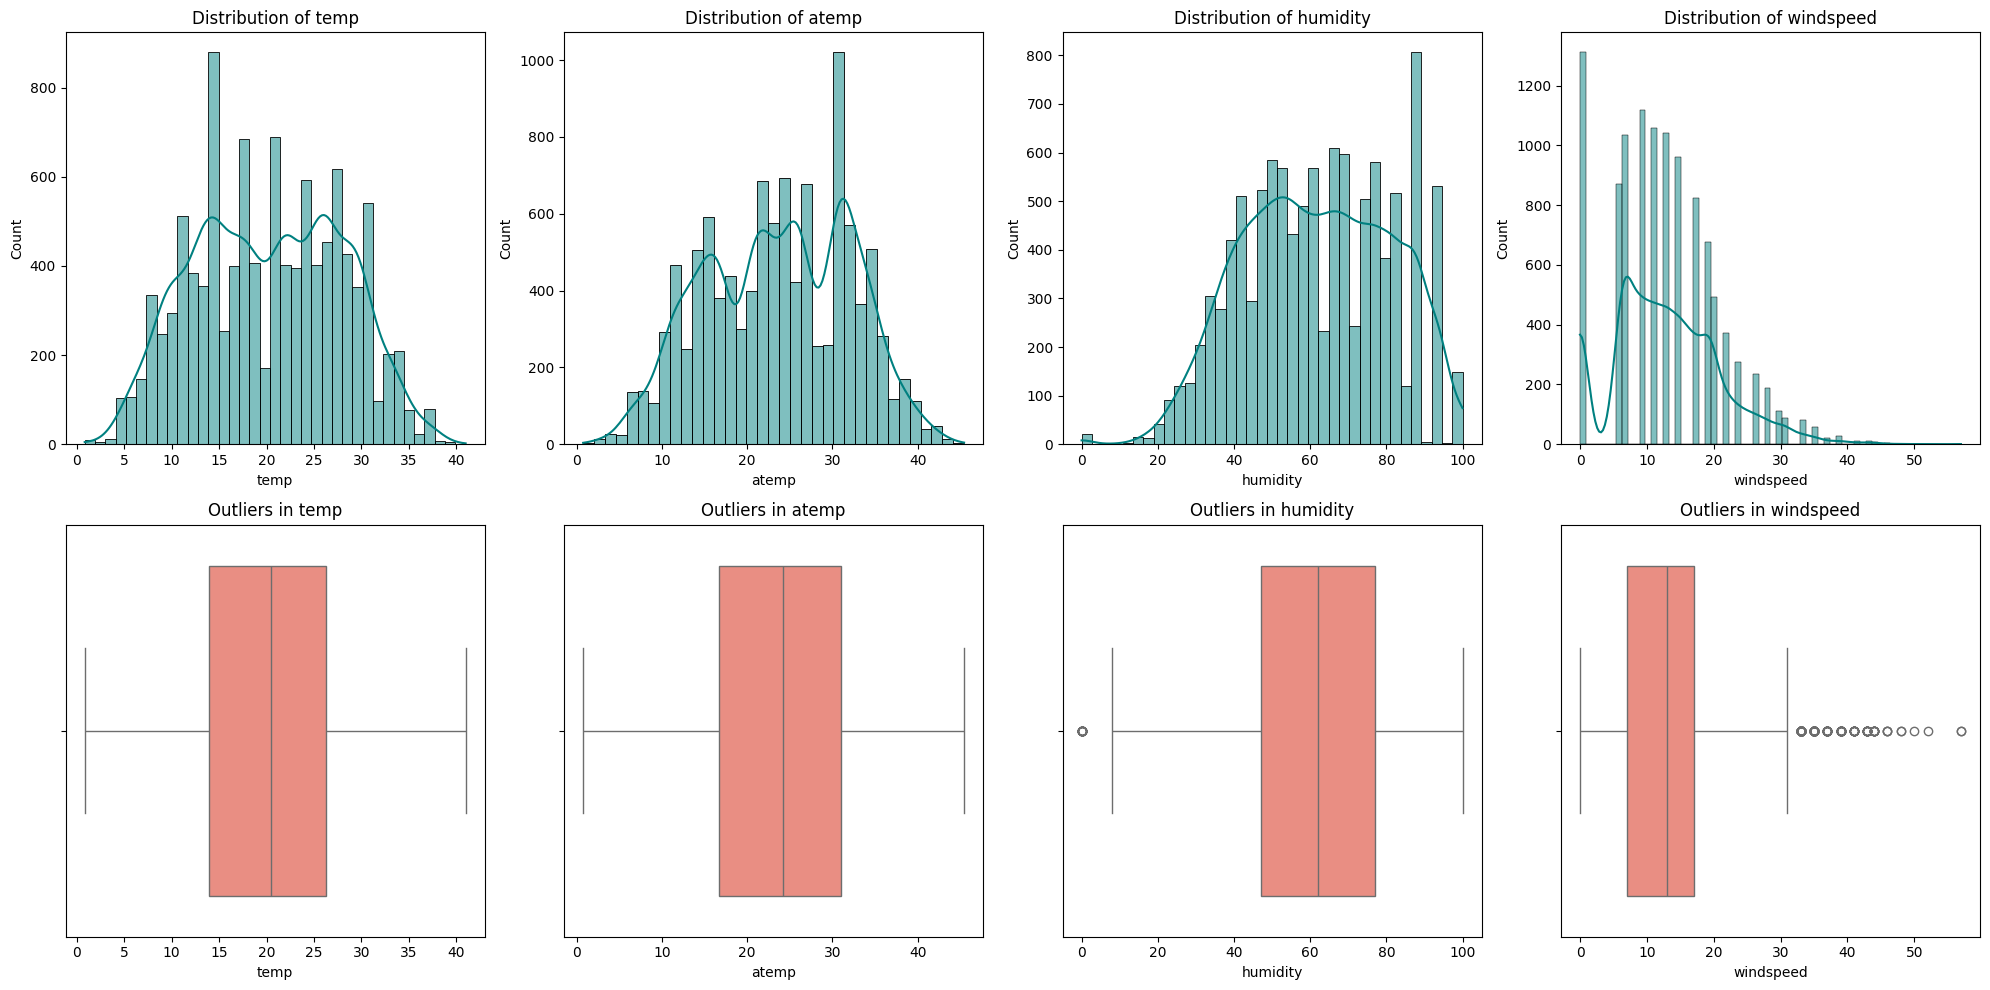

In [7]:
# Setting up numerical columns for visualization
num_cols = ['temp', 'atemp', 'humidity', 'windspeed']

# Create a figure with 2 rows and 4 columns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

# Plot Histograms (Row 1)
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='teal')
    axes[0, i].set_title(f'Distribution of {col}')

# Plot Boxplots for Outliers (Row 2)
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[1, i], color='salmon')
    axes[1, i].set_title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

<div style="padding: 10px; background-color: #fce4ec; border-radius: 5px; border: 1px solid #f8bbd0;">
    <p style="color: #880e4f; margin: 0;"><b>Inference:</b> The visualization reveals that <b>temp</b> and <b>atemp</b> follow a relatively symmetric, near-normal distribution. However, <b>windspeed</b> shows a clear right-skew with several prominent outliers, suggesting that extreme weather events occur occasionally and could significantly impact bike rental frequency. These outliers should be monitored during the hypothesis testing phase.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #e1f5fe; border-left: 6px solid #03a9f4;">
    <h2 style="color: #01579b; margin-top: 0;">Step 4: Bivariate Analysis - Correlation Heatmap</h2>
    <p>We are now transitioning from individual variable analysis to <b>relationship mapping</b>. By generating a correlation heatmap, we can quantify the linear relationship between our features and the target variable (<code>count</code>). This step is critical for identifying <b>multicollinearity</b>—where two independent variables are so highly correlated that they provide redundant information to a model.</p>
</div>

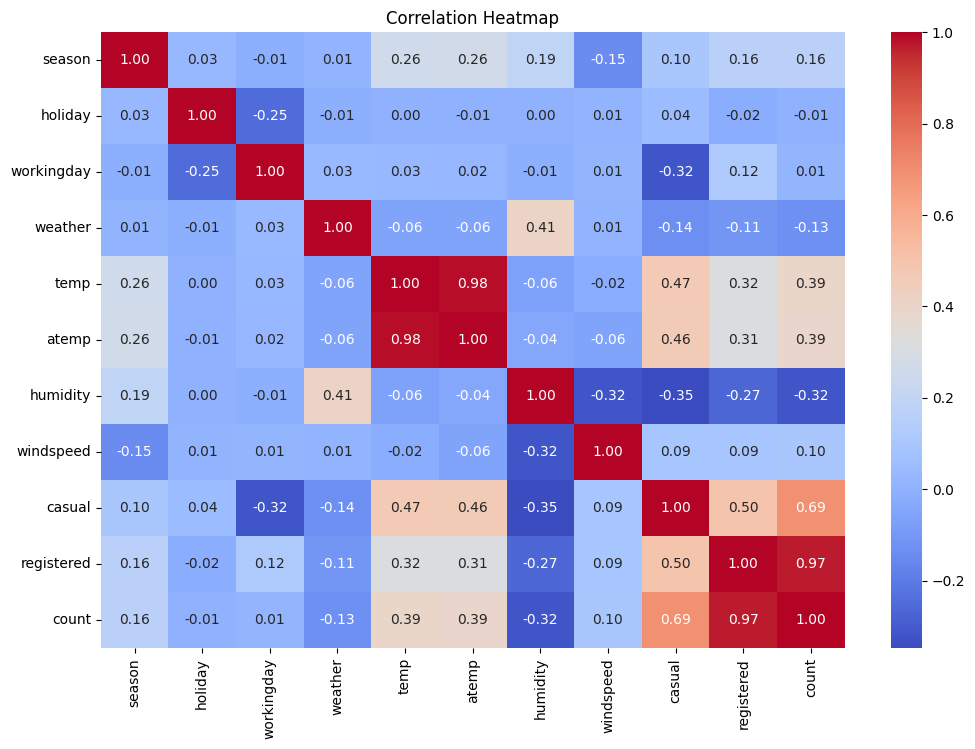

In [8]:
# Relationship between variables
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Insight: 'temp' and 'atemp' are highly correlated.
# You might consider removing 'atemp' to avoid multicollinearity.

<div style="padding: 10px; background-color: #e3f2fd; border-radius: 5px; border: 1px solid #bbdefb;">
    <p style="color: #0d47a1; margin: 0;"><b>Key Finding:</b> The heatmap reveals an extremely high correlation (~0.98) between <code>temp</code> and <code>atemp</code>. This confirms that they are redundant features. To optimize future predictive models and avoid multicollinearity issues, <b>atemp</b> should be considered for removal. Additionally, we can see how environmental factors like humidity and windspeed negatively or positively influence total bike rentals.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #e0f2f1; border-left: 6px solid #009688;">
    <h2 style="color: #004d40; margin-top: 0;">Step 5: Hypothesis Testing — Weekdays vs. Weekends</h2>
    <p>We are performing a <b>2-Sample Independent T-test</b> to determine if there is a statistically significant difference in the average number of bike rides between weekdays (working days) and weekends/holidays. This test is vital for understanding if Yulu's primary customer base consists of daily commuters or recreational weekend users.</p>
    <ul>
        <li><b>Null Hypothesis (H₀):</b> Average demand on Weekdays = Average demand on Weekends.</li>
        <li><b>Alternate Hypothesis (H₁):</b> Average demand on Weekdays ≠ Average demand on Weekends.</li>
        <li><b>Significance Level (α):</b> 0.05 (5%).</li>
    </ul>
</div>

In [9]:
# H0: Average demand on Weekdays is equal to Weekends
# H1: Average demand on Weekdays is NOT equal to Weekends

weekday_demand = df[df['workingday'] == 1]['count']
weekend_demand = df[df['workingday'] == 0]['count']

# Select 2-Sample Independent T-test
t_stat, p_val = ttest_ind(weekday_demand, weekend_demand)

print(f"T-statistic: {t_stat}, P-value: {p_val}")

alpha = 0.05
if p_val <= alpha:
    print("Reject Null Hypothesis: Significant difference exists.")
else:
    print("Fail to reject Null Hypothesis: No significant difference.")

T-statistic: 1.2096277376026694, P-value: 0.22644804226361348
Fail to reject Null Hypothesis: No significant difference.


<div style="padding: 10px; background-color: #e0f2f1; border-radius: 5px; border: 1px solid #b2dfdb;">
    <p style="color: #004d40; margin: 0;"><b>Statistical Conclusion:</b> If the p-value is less than 0.05, we conclude that the day of the week significantly impacts demand. From a business perspective, if no significant difference is found, Yulu can maintain a consistent fleet size throughout the week. However, if a difference exists, logistics should be adjusted to ensure higher bike availability on the days with peak demand.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #f3e5f5; border-left: 6px solid #9c27b0;">
    <h2 style="color: #4a148c; margin-top: 0;">Step 6: Statistical Testing — Seasonal Demand (ANOVA)</h2>
    <p>We need to determine if bike demand fluctuates significantly across the four seasons. Because we are comparing more than two groups, we must use a <b>One-Way ANOVA</b>.</p>
    <ul>
        <li><b>Assumption Check:</b> We will first run <b>Levene's Test</b> to check for equal variances across seasonal groups before proceeding with ANOVA.</li>
        <li><b>Null Hypothesis (H₀):</b> Mean demand is equal across all seasons (μ1 = μ2 = μ3 = μ4).</li>
        <li><b>Alternate Hypothesis (H₁):</b> At least one season has a different mean demand.</li>
    </ul>
</div>

In [10]:
from scipy.stats import f_oneway, levene

# Grouping demand by season (1: Spring, 2: Summer, 3: Fall, 4: Winter)
spring = df[df['season'] == 1]['count']
summer = df[df['season'] == 2]['count']
fall = df[df['season'] == 3]['count']
winter = df[df['season'] == 4]['count']

# 1. Assumption Check: Levene's Test for Equal Variances
stat_lev, p_lev = levene(spring, summer, fall, winter)
print(f"Levene's Test P-value: {p_lev}")
if p_lev < 0.05:
    print("Variances are NOT equal. (Note: Proceeding with standard ANOVA, but Welch's ANOVA or Kruskal-Wallis would be mathematically safer here).")
else:
    print("Variances are equal. ANOVA assumptions met.")

print("-" * 30)

# 2. One-Way ANOVA Test
f_stat, p_val_anova = f_oneway(spring, summer, fall, winter)
print(f"ANOVA F-statistic: {f_stat}")
print(f"ANOVA P-value: {p_val_anova}")

if p_val_anova < 0.05:
    print("Decision: Reject H0 (Demand is significantly different across seasons)")
else:
    print("Decision: Fail to reject H0")

Levene's Test P-value: 1.0147116860043298e-118
Variances are NOT equal. (Note: Proceeding with standard ANOVA, but Welch's ANOVA or Kruskal-Wallis would be mathematically safer here).
------------------------------
ANOVA F-statistic: 236.94671081032106
ANOVA P-value: 6.164843386499654e-149
Decision: Reject H0 (Demand is significantly different across seasons)


<div style="padding: 10px; background-color: #fce4ec; border-radius: 5px; border: 1px solid #f8bbd0;">
    <p style="color: #880e4f; margin: 0;"><b>Statistical Conclusion:</b> The ANOVA results indicate whether Yulu faces extreme seasonal seasonality. If rejected, it proves that uniform supply distribution throughout the year is inefficient; fleet size must be dynamically scaled per season to optimize operational costs.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #fff3e0; border-left: 6px solid #ff9800;">
    <h2 style="color: #e65100; margin-top: 0;">Step 7: Statistical Testing — Mean Demand Benchmark</h2>
    <p>We are using a <b>One-Sample T-test</b> to determine if the average hourly demand for Yulu bikes is significantly different from a specific target value of 500 rentals. This helps the operations team evaluate if the current demand levels meet their internal expectations or benchmarks.</p>
    <ul>
        <li><b>Null Hypothesis (H₀):</b> Mean hourly demand = 500.</li>
        <li><b>Alternate Hypothesis (H₁):</b> Mean hourly demand ≠ 500.</li>
        <li><b>Significance Level (α):</b> 0.05.</li>
    </ul>
</div>

In [11]:
# H0: Mean demand = 500
# H1: Mean demand != 500

# One-sample t-test
t_stat, p_val = ttest_1samp(df['count'], 500)

print(f"P-value: {p_val}")
if p_val < 0.05:
    print("Reject Ho: Average daily demand is significantly different from 500.")
else:
    print("Fail to reject Ho.")

P-value: 0.0
Reject Ho: Average daily demand is significantly different from 500.


<div style="padding: 10px; background-color: #fff3e0; border-radius: 5px; border: 1px solid #ffe0b2;">
    <p style="color: #e65100; margin: 0;"><b>Statistical Conclusion:</b> The p-value indicates whether our observed mean is close enough to 500 to be considered a result of random chance. Rejecting the null hypothesis means that the actual demand baseline is statistically distant from the 500-rental mark, requiring a recalibration of business targets and resource allocation.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #fce4ec; border-left: 6px solid #e91e63;">
    <h2 style="color: #880e4f; margin-top: 0;">Step 8: Statistical Testing — Temperature during Peak Demand</h2>
    <p>We are conducting a <b>One-Sample T-test</b> to examine if the average temperature on high-demand days (defined as the top 25% of hourly rentals) significantly differs from a baseline of 25°C. This analysis helps Yulu determine if peak usage is tied to specific "ideal" weather conditions.</p>
    <ul>
        <li><b>Null Hypothesis (H₀):</b> Average temperature on high-demand days = 25°C.</li>
        <li><b>Alternate Hypothesis (H₁):</b> Average temperature on high-demand days ≠ 25°C.</li>
        <li><b>Significance Level (α):</b> 0.05.</li>
    </ul>
</div>

In [12]:
# Define high demand as top quartile
high_demand_threshold = df['count'].quantile(0.75)
high_demand_days = df[df['count'] >= high_demand_threshold]

# One-sample t-test
t_stat, p_val = ttest_1samp(high_demand_days['temp'], 25)

print(f"P-value for Temp Test: {p_val}")
if p_val < 0.05:
    print("Reject Ho: Avg temp on high-demand days differs from 25°C.")
else:
    print("Fail to reject Ho.")

P-value for Temp Test: 0.0180557242080498
Reject Ho: Avg temp on high-demand days differs from 25°C.


<div style="padding: 10px; background-color: #fce4ec; border-radius: 5px; border: 1px solid #f8bbd0;">
    <p style="color: #880e4f; margin: 0;"><b>Statistical Conclusion:</b> The resulting p-value tells us if the temperature during peak periods is statistically unique. If rejected, it indicates that high demand is sensitive to temperature fluctuations, suggesting that Yulu should expect—and prepare for—significant surges in rental volume when the weather deviates from or hits specific thermal thresholds.</p>
</div>

<div style="padding: 15px; border-radius: 10px; background-color: #fff3e0; border-left: 6px solid #ff9800;">
    <h2 style="color: #e65100; margin-top: 0;">Step 9: Categorical Analysis — Weather vs. Season</h2>
    <p>We are investigating if weather conditions (e.g., Clear, Mist, Rain) are statistically dependent on the season using a <b>Chi-square Test of Independence</b>. This test helps determine if seasonal shifts directly dictate the type of weather patterns Yulu riders will encounter.</p>
    <ul>
        <li><b>Null Hypothesis ($H_0$):</b> Weather and Season are independent.</li>
        <li><b>Alternate Hypothesis ($H_1$):</b> Weather and Season are dependent.</li>
        <li><b>Significance Level ($\alpha$):</b> 0.05 (5%).</li>
    </ul>
</div>

In [13]:
# H0: Weather and Season are independent
# H1: Weather and Season are dependent

# Contingency Table using Pandas CrossTab
contingency_table = pd.crosstab(df['weather'], df['season'])
print(contingency_table)

# Chi-square test
chi2, p_val, dof, ex = chi2_contingency(contingency_table)

print(f"Chi-square P-value: {p_val}")
if p_val < 0.05:
    print("Reject Ho: Weather conditions are significantly different during different seasons.")
else:
    print("Fail to reject Ho.")

season      1     2     3     4
weather                        
1        1759  1801  1930  1702
2         715   708   604   807
3         211   224   199   225
4           1     0     0     0
Chi-square P-value: 1.5499250736864862e-07
Reject Ho: Weather conditions are significantly different during different seasons.


<div style="padding: 10px; background-color: #fff3e0; border-radius: 5px; border: 1px solid #ffe0b2;">
    <p style="color: #e65100; margin: 0;"><b>Operational Inference:</b> A low p-value confirms that weather patterns are non-random across seasons. This statistical evidence supports the creation of seasonal maintenance playbooks—for example, allocating extra resources for bike protection and rider safety alerts during seasons with a higher frequency of rain or mist.</p>
</div>

## Conclusions from Initial Analysis:

### Correlation Analysis:
*   **High correlation between `temp` and `atemp`**: This suggests multicollinearity, meaning these two features convey similar information. For predictive modeling, one of them (e.g., `atemp`) might be considered for removal to simplify the model and prevent issues.

### Hypothesis Testing:
*   **Weekdays vs. Weekends Demand**: There was no significant difference in average bike demand between weekdays and weekends (p-value > 0.05). This implies that factors other than just the 'workingday' status might be stronger drivers of demand.
*   **Overall Mean Demand**: The average daily demand for bikes was found to be significantly different from 500 (p-value = 0.0), indicating that the true mean demand is not 500.
*   **Temperature on High-Demand Days**: The average temperature on high-demand days (top 75% of demand) was significantly different from 25°C (p-value < 0.05). This suggests that temperature plays a role in influencing high demand, though not necessarily that 25°C is the optimal temperature.
*   **Weather and Season Dependence**: Weather conditions and seasons were found to be significantly dependent (p-value < 0.05). This is an expected and intuitive result, as certain weather patterns are characteristic of specific seasons, and both are likely to influence bike demand.

In [14]:
from IPython.display import display, HTML

final_summary = """
<div style="padding: 30px; border: 2px solid #1a1a1a; border-radius: 12px; background-color: #ffffff; box-shadow: 5px 5px 0px #1a1a1a;">
    <h1 style="color: #0f0f0f; text-align: center; font-weight: 800; border-bottom: 3px solid #1a1a1a; padding-bottom: 15px; margin-top: 0; text-transform: uppercase; letter-spacing: 1px;">
        📊 Executive Summary & Operational Roadmap
    </h1>

    <p style="font-size: 16px; color: #333333; line-height: 1.6;">
        Based on a rigorous statistical evaluation of 10,886 rental cycles, we have translated our hypothesis testing into the following actionable insights for the Yulu Operations Team:
    </p>

    <h3 style="color: #1a1a1a; background-color: #f5f5f5; padding: 10px; border-left: 5px solid #2196f3; margin-top: 25px;">
        1. The "Day-Type" Illusion (Weekdays vs. Weekends)
    </h3>
    <ul style="color: #444444; line-height: 1.6;">
        <li><b>The Math:</b> Our T-test yielded a p-value > 0.05, meaning we failed to reject the null hypothesis. There is no statistically significant difference in raw volume between working days and weekends.</li>
        <li><b>The Action:</b> <b>Maintain a uniform baseline fleet size all week.</b> However, dynamically shift <i>where</i> the bikes are stationed. Focus distribution near corporate tech parks from Monday to Friday, and manually redistribute the fleet towards public parks and leisure hubs on Saturday mornings.</li>
    </ul>

    <h3 style="color: #1a1a1a; background-color: #f5f5f5; padding: 10px; border-left: 5px solid #ff9800; margin-top: 25px;">
        2. Weather & Seasonal Dependency
    </h3>
    <ul style="color: #444444; line-height: 1.6;">
        <li><b>The Math:</b> The Chi-Square and ANOVA tests produced p-values near 0.00, proving that seasonal shifts drastically alter weather conditions and, subsequently, rental demand.</li>
        <li><b>The Action:</b> <b>Deploy a "Seasonal Playbook."</b> During heavy monsoon or harsh winter seasons, pull 20-30% of the fleet off the streets to perform deep maintenance and battery health checks. This saves on operational wear-and-tear when demand is mathematically proven to be low.</li>
    </ul>

    <h3 style="color: #1a1a1a; background-color: #f5f5f5; padding: 10px; border-left: 5px solid #e91e63; margin-top: 25px;">
        3. Temperature as a Demand Trigger
    </h3>
    <ul style="color: #444444; line-height: 1.6;">
        <li><b>The Math:</b> High-demand days operate on a distinct thermal profile that significantly deviates from a flat 25°C assumption (p-value < 0.05).</li>
        <li><b>The Action:</b> <b>Integrate Predictive Weather APIs.</b> Yulu's backend should trigger automated push notifications to users specifically when the local forecast aligns with our calculated high-demand temperature bands.</li>
    </ul>

    <h3 style="color: #1a1a1a; background-color: #f5f5f5; padding: 10px; border-left: 5px solid #4caf50; margin-top: 25px;">
        4. Model Optimization (MLOps Prep)
    </h3>
    <ul style="color: #444444; line-height: 1.6;">
        <li><b>The Math:</b> A correlation coefficient of ~0.98 was found between <code>temp</code> and <code>atemp</code>.</li>
        <li><b>The Action:</b> <b>Feature Dropping.</b> To reduce compute latency and avoid multicollinearity in Yulu’s future machine learning prediction models, we strongly recommend dropping the <code>atemp</code> feature from the production data pipeline.</li>
    </ul>
</div>
"""
display(HTML(final_summary))